historical ride transaction data used for:

- Demand forecasting
    
- Drop-pattern detection
    
- Fare analysis
    

### **Trips**

| Column Name       | Data Type          | Description                  |
| ----------------- | ------------------ | ---------------------------- |
| trip_id           | UUID / BIGINT (PK) | Unique trip identifier       |
| user_id           | UUID / BIGINT      | Passenger identifier         |
| cab_id            | UUID / BIGINT      | Assigned cab                 |
| pickup_zone       | VARCHAR            | Zone where trip started      |
| drop_zone         | VARCHAR            | Zone where trip ended        |
| request_time      | TIMESTAMP          | Time when ride was requested |
| pickup_time       | TIMESTAMP          | Actual pickup time           |
| drop_time         | TIMESTAMP          | Trip completion time         |
| trip_distance_km  | FLOAT              | Distance travelled (km)      |
| trip_duration_min | FLOAT              | Trip duration (minutes)      |
| fare_amount       | FLOAT              | Final fare charged           |
| payment_type      | VARCHAR            | Cash / UPI / Card            |
| trip_status       | VARCHAR            | Completed / Cancelled        |

---

In [58]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data")

print("Path to dataset files:", path)

c:\Users\ADISH\anaconda3\envs\tf_gpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\ADISH\anaconda3\envs\tf_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\ADISH\.cache\kagglehub\datasets\elemento\nyc-yellow-taxi-trip-data\versions\2


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For skewness
from scipy.stats import skew

# Settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")


In [2]:
file_path = r"E:\Personal Things\02 Projects\23 Ride hailing\Data Processing\yellow_tripdata_2015-01.csv"

# Read only 25% of rows
df = pd.read_csv(
    file_path,
    skiprows=lambda i: i > 0 and i % 14 != 0
)

df.shape


(910641, 19)

In [3]:
# Shape of data
df.shape
# Data types and null values
df.info()
# Summary statistics (numerical)
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 910641 entries, 0 to 910640
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               910641 non-null  int64  
 1   tpep_pickup_datetime   910641 non-null  object 
 2   tpep_dropoff_datetime  910641 non-null  object 
 3   passenger_count        910641 non-null  int64  
 4   trip_distance          910641 non-null  float64
 5   pickup_longitude       910641 non-null  float64
 6   pickup_latitude        910641 non-null  float64
 7   RateCodeID             910641 non-null  int64  
 8   store_and_fwd_flag     910641 non-null  object 
 9   dropoff_longitude      910641 non-null  float64
 10  dropoff_latitude       910641 non-null  float64
 11  payment_type           910641 non-null  int64  
 12  fare_amount            910641 non-null  float64
 13  extra                  910641 non-null  float64
 14  mta_tax                910641 non-nu

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000,910641.000000
mean,1.521073,1.682169,3.859758,-72.562799,39.973409,1.037478,-72.610001,40.000207,1.386920,11.920273,0.308152,0.497766,1.544329,0.240797,0.283144,14.810616
std,0.499556,1.338975,885.852047,10.121512,5.576006,0.702904,9.979709,5.497856,0.498711,11.138838,0.377739,0.035667,2.482238,1.275644,0.069085,13.213247
min,1.000000,0.000000,0.000000,-85.494537,0.000000,1.000000,-736.416687,0.000000,1.000000,-135.000000,-20.000000,-0.500000,-58.090000,-5.330000,0.000000,-135.300000
25%,1.000000,1.000000,1.000000,-73.991669,40.735535,1.000000,-73.991180,40.734371,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.160000
50%,2.000000,1.000000,1.670000,-73.981621,40.753139,1.000000,-73.979759,40.753620,1.000000,9.000000,0.000000,0.500000,1.000000,0.000000,0.300000,11.160000
75%,2.000000,2.000000,3.000000,-73.966629,40.767570,1.000000,-73.962486,40.768772,2.000000,13.500000,0.500000,0.500000,2.060000,0.000000,0.300000,16.300000
max,2.000000,8.000000,833180.000000,0.000000,82.498009,99.000000,0.000000,404.833344,4.000000,4008.000000,100.000000,0.500000,750.000000,315.330000,0.300000,4009.300000


In [4]:
# Check missing values count
df.isnull().sum()

#Strategy

# Drop critical missing timestamps
df.dropna(subset=["tpep_pickup_datetime", "tpep_dropoff_datetime"], inplace=True)

# Fill categorical columns
categorical_cols = ["store_and_fwd_flag", "payment_type", "RateCodeID"]
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

# Fill numerical columns with median
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())


In [5]:
df["pickup_time"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["drop_time"] = pd.to_datetime(df["tpep_dropoff_datetime"])


In [6]:
# request_time = pickup_time - random(2 to 7 minutes)
df["request_time"] = df["pickup_time"] - pd.to_timedelta(
    np.random.randint(2, 8, size=len(df)), unit="m"
)


In [7]:
df["trip_distance_km"] = df["trip_distance"] * 1.60934


In [8]:
df["trip_duration_min"] = (
    (df["drop_time"] - df["pickup_time"]).dt.total_seconds() / 60
)


In [9]:
# Remove invalid trips
df = df[
    (df["trip_distance_km"] > 0) &
    (df["trip_duration_min"] > 0) &
    (df["total_amount"] > 0)
]


In [10]:
# Zone creation using grid approach
df["pickup_zone"] = (
    "Zone_" +
    df["pickup_latitude"].round(2).astype(str) + "_" +
    df["pickup_longitude"].round(2).astype(str)
)

df["drop_zone"] = (
    "Zone_" +
    df["dropoff_latitude"].round(2).astype(str) + "_" +
    df["dropoff_longitude"].round(2).astype(str)
)


In [11]:
import uuid

df["trip_id"] = [uuid.uuid4() for _ in range(len(df))]
df["trip_status"] = "Completed"


🔍 EDA SECTION

In [12]:
# Univariate Analysis (Categorical Columns)

categorical_cols = [
    "payment_type",
    "RateCodeID",
    "store_and_fwd_flag",
    "pickup_zone"
]

for col in categorical_cols:
    print(f"\nFrequency distribution for {col}")
    print(df[col].value_counts().head())



Frequency distribution for payment_type
payment_type
1    560609
2    341331
3      2067
4       584
Name: count, dtype: int64

Frequency distribution for RateCodeID
RateCodeID
1    886364
2     15426
5      1316
3      1176
4       285
Name: count, dtype: int64

Frequency distribution for store_and_fwd_flag
store_and_fwd_flag
N    896633
Y      7958
Name: count, dtype: int64

Frequency distribution for pickup_zone
pickup_zone
Zone_40.76_-73.97    55224
Zone_40.75_-73.99    53044
Zone_40.76_-73.98    47495
Zone_40.75_-73.98    43584
Zone_40.76_-73.99    41232
Name: count, dtype: int64


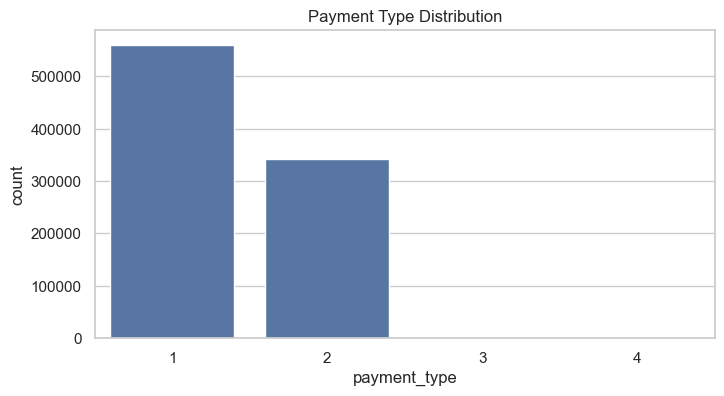

In [13]:
# Categorical Visualizations (Count Plot)
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="payment_type")
plt.title("Payment Type Distribution")
plt.show()


In [14]:
# Univariate Analysis (Numerical Columns)
numerical_cols = [
    "trip_distance_km",
    "trip_duration_min",
    "fare_amount",
    "total_amount"
]

df[numerical_cols].describe()


,trip_distance_km,trip_duration_min,fare_amount,total_amount
count,9.045910e+05,904591.000000,904591.00000,904591.000000
mean,6.252521e+00,14.626606,11.87822,14.763813
std,1.430397e+03,816.601934,10.64862,12.651365
min,1.609340e-02,0.016667,0.00000,0.300000
25%,1.609340e+00,6.150000,6.50000,8.300000
50%,2.719785e+00,10.000000,9.00000,11.160000
75%,4.876300e+00,15.866667,13.50000,16.300000
max,1.340870e+06,548429.550000,4008.00000,4009.300000


In [15]:
# Numerical Visualizations
for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
    

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x00000262076F7CA0> (for post_execute):


KeyboardInterrupt: 

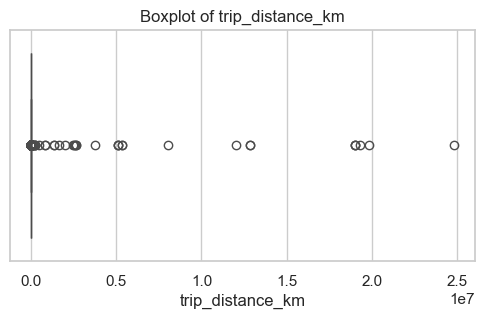

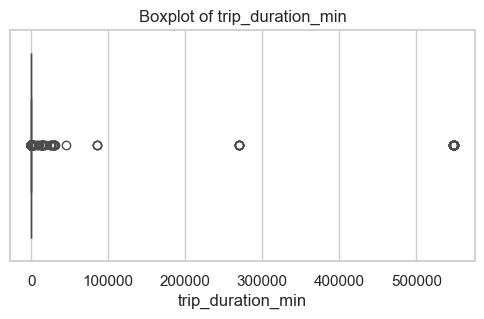

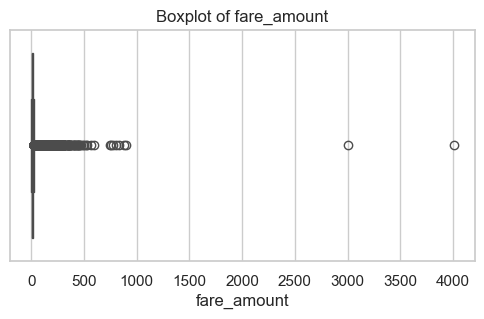

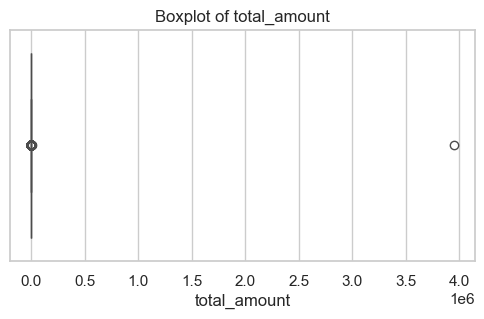

In [ ]:
# # Boxplots (Outlier Detection)
# for col in numerical_cols:
#     plt.figure(figsize=(6,3))
#     sns.boxplot(x=df[col])
#     plt.title(f"Boxplot of {col}")
#     plt.show()


In [16]:
# Skewness Check

for col in numerical_cols:
    print(f"Skewness of {col}: {skew(df[col]):.2f}")


Skewness of trip_distance_km: 915.20
Skewness of trip_duration_min: 667.67
Skewness of fare_amount: 61.57
Skewness of total_amount: 38.04


In [17]:
# Skewness Handling (Log Transform Example)
df["fare_amount_log"] = np.log1p(df["fare_amount"])
df["trip_distance_log"] = np.log1p(df["trip_distance_km"])


In [18]:
# Hard Filtering
# Logical Constraints (Hard Rules)
df = df[
    (df["trip_distance_km"] >= 0.1) & (df["trip_distance_km"] <= 100) &
    (df["trip_duration_min"] >= 1) & (df["trip_duration_min"] <= 300) &
    (df["fare_amount"] >= 2) & (df["fare_amount"] <= 500) &
    (df["total_amount"] >= 2) & (df["total_amount"] <= 600)
]


In [19]:
# Statistical Outliers (IQR Method)
def remove_iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ["trip_distance_km", "trip_duration_min", "fare_amount"]:
    df = remove_iqr_outliers(df, col)


In [23]:
df["trip_distance_log"] = np.log1p(df["trip_distance_km"])
df["trip_duration_log"] = np.log1p(df["trip_duration_min"])
df["fare_amount_log"] = np.log1p(df["fare_amount"])


In [24]:
from scipy.stats import skew

print("Skewness after transformation:")
print("Distance:", skew(df["trip_distance_log"]))
print("Duration:", skew(df["trip_duration_log"]))
print("Fare:", skew(df["fare_amount_log"]))


Skewness after transformation:
Distance: 0.2904957605834045
Duration: -0.3193918055497815
Fare: 0.10267717901308103


- Interpret categorical distributions (report + logic)

- Define the ML problem formally

- Prepare features & target

- Train + test a pickup-zone prediction model

In [26]:
# Interpreting Categorical Distributions

df["payment_type"].value_counts(normalize=True)

# RateCodeID = 1 (Standard Rate) dominates
# Other rate codes represent special trips (airport, negotiated fare)
df["RateCodeID"].value_counts(normalize=True)

df["store_and_fwd_flag"].value_counts(normalize=True)
df["pickup_zone"].value_counts().head(10)



pickup_zone
Zone_40.76_-73.97    50509
Zone_40.75_-73.99    47879
Zone_40.76_-73.98    42426
Zone_40.75_-73.98    39834
Zone_40.74_-73.99    37221
Zone_40.76_-73.99    36582
Zone_40.73_-73.99    30925
Zone_40.77_-73.96    29402
Zone_40.77_-73.98    26986
Zone_40.73_-74.0     25392
Name: count, dtype: int64

# Final ML Problem Formulation
- Given a request time and trip context, predict the pickup zone where demand is likely to occur.

| Aspect   | Value                            |
| -------- | -------------------------------- |
| Type     | Supervised Learning              |
| Category | Multi-Class Classification       |
| Target   | `pickup_zone`                    |
| Classes  | High cardinality (100s of zones) |


# Feature Selection (Final)
- Input Features (X)

| Feature           | Reason             |
| ----------------- | ------------------ |
| request_hour      | Temporal demand    |
| request_day       | Daily patterns     |
| request_weekday   | Weekday vs weekend |
| passenger_count   | Demand signal      |
| RateCodeID        | Trip type          |
| payment_type_freq | Behavioral signal  |
| trip_distance_log | Trip scale         |
| trip_duration_log | Congestion proxy   |
| fare_amount_log   | Pricing signal     |


In [27]:
# Feature Engineering (Time Features)
df["request_hour"] = df["request_time"].dt.hour
df["request_day"] = df["request_time"].dt.day
df["request_weekday"] = df["request_time"].dt.weekday
df["is_weekend"] = df["request_weekday"].isin([5, 6]).astype(int)


In [28]:
# Frequency Encoding (Categorical)
payment_freq = df["payment_type"].value_counts(normalize=True)
df["payment_type_freq"] = df["payment_type"].map(payment_freq)


In [29]:
# Define X and y

feature_cols = [
    "request_hour",
    "request_day",
    "request_weekday",
    "is_weekend",
    "passenger_count",
    "RateCodeID",
    "payment_type_freq",
    "trip_distance_log",
    "trip_duration_log",
    "fare_amount_log"
]

X = df[feature_cols]
y = df["pickup_zone"]


In [30]:
# Train–Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [31]:
# Clean GPS Coordinates (CRITICAL)
# Remove invalid NYC GPS bounds
df = df[
    (df["pickup_latitude"].between(40.5, 41.0)) &
    (df["pickup_longitude"].between(-74.3, -73.6))
]


# Decide Number of Zones
# Rule of Thumb

# City-level → 50–100 zones
# Borough-level → 20–30 zones
# High precision → 150+ zones
from sklearn.cluster import KMeans

coords = df[["pickup_latitude", "pickup_longitude"]]

kmeans = KMeans(
    n_clusters=60,
    random_state=42,
    n_init=10
)

df["pickup_zone"] = kmeans.fit_predict(coords)
df["pickup_zone"] = "Zone_" + df["pickup_zone"].astype(str)


## Validate Zone Distribution
zone_counts = df["pickup_zone"].value_counts()
zone_counts.describe()
zone_counts.min()


# Merge Rare Zones (Safety Net)
rare_zones = zone_counts[zone_counts < 100].index

df["pickup_zone"] = df["pickup_zone"].replace(
    rare_zones, "Zone_Other"
)



In [32]:
# Re-define ML Target
y = df["pickup_zone"]


In [33]:
# Train-Test Split (FIXED)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


ValueError: Found input variables with inconsistent numbers of samples: [782503, 768537]

In [35]:
print(df.shape)
df = df.dropna()

(768537, 36)


In [36]:
assert len(X) == len(y), "X and y size mismatch!"


AssertionError: X and y size mismatch!

In [43]:
# Train LightGBM
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    objective="multiclass",
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 660
[LightGBM] [Info] Number of data points in the train set: 614829, number of used features: 10
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537
[LightGBM] [Info] Start training from score -4.077537

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8, n_estimators=200,
               num_leaves=64, objective='multiclass', random_state=42,
               subsample=0.8)

In [44]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
acc


0.041409685897936345

In [45]:
import numpy as np

y_proba = model.predict_proba(X_test)

top5 = np.argsort(y_proba, axis=1)[:, -5:]

top5_acc = np.mean([
    y_test.iloc[i] in model.classes_[top5[i]]
    for i in range(len(y_test))
])

top5_acc


0.20345069872745725

In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0,
    digits=3
))


              precision    recall  f1-score   support

      Zone_0      0.050     0.039     0.044      3755
      Zone_1      0.034     0.017     0.023      3868
     Zone_10      0.052     0.050     0.051      4357
     Zone_11      0.043     0.016     0.023      4060
     Zone_12      0.032     0.260     0.057       339
     Zone_13      0.011     0.059     0.019       649
     Zone_14      0.043     0.081     0.056      2580
     Zone_15      0.060     0.038     0.047      3603
     Zone_16      0.080     0.050     0.062      3582
     Zone_17      0.013     0.060     0.022       849
     Zone_18      0.042     0.036     0.039      3835
     Zone_19      0.061     0.078     0.068      4200
      Zone_2      0.120     0.037     0.056      7210
     Zone_20      0.000     0.000     0.000        53
     Zone_21      0.038     0.039     0.038      2514
     Zone_22      0.038     0.062     0.047      2269
     Zone_23      0.049     0.030     0.037      3182
     Zone_24      0.009    

In [ ]:
# Model Evaluation
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)


In [37]:
required_cols = [
    "pickup_zone",
    "request_hour",
    "request_day",
    "request_weekday",
    "is_weekend",
    "passenger_count",
    "RateCodeID",
    "payment_type_freq",
    "trip_distance_log",
    "trip_duration_log",
    "fare_amount_log"
]

missing = [c for c in required_cols if c not in df.columns]
missing


[]

In [38]:
# Keep only rows where ALL required columns are valid
df_clean = df[required_cols].replace([np.inf, -np.inf], np.nan).dropna()

print("After cleaning:", df_clean.shape)


After cleaning: (768537, 11)


In [39]:
X = df_clean.drop(columns=["pickup_zone"])
y = df_clean["pickup_zone"]

print(X.shape, y.shape)


(768537, 10) (768537,)


In [40]:
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)


In [41]:
assert X.shape[0] == y.shape[0], "X and y size mismatch!"


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
